In [13]:
from typing import  TypedDict
from langgraph.graph import StateGraph,START,END

In [14]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    number3 : int
    number4 : int
    operator1 : str
    operator2 : str
    result1 : int
    result2 : int

In [15]:
def adder1 (state: TypedDict) -> TypedDict:
    """
    This function adds two numbers
    """
    state["result1"] = state["number1"] +  state["number2"]

    return state


def adder2 (state: TypedDict) -> TypedDict:
    """
    This function adds two numbers
    """
    state["result2"] = state["number3"] +  state["number4"]

    return state


def substractor1 (state: TypedDict) -> TypedDict:
    """
    This function adds two numbers
    """
    state["result1"] = state["number1"] -  state["number2"]

    return state


def substractor2 (state: TypedDict) -> TypedDict:
    """
    This function adds two numbers
    """
    state["result2"] = state["number3"] -  state["number4"]

    return state


def operation_execute1 (state: TypedDict) -> TypedDict:
    """
    This function acts as a route for the first operation
    """

    if state["operator1"] == "+":
        return "addition_operation-1"
    elif state["operator1"] == "-":
        return "substractor_operation-1"



def operation_execute2 (state: TypedDict) -> TypedDict:
    """
    This function acts as a route for the first operation
    """

    if state["operator2"] == "+":
        return "addition_operation-2"
    elif state["operator2"] == "-":
        return "substractor_operation-2"

In [16]:
graph = StateGraph(AgentState)


graph.add_node("router1",lambda state:state)
graph.add_node("router2",lambda state:state)


graph.add_node("add_node-1",adder1)
graph.add_node("add_node-2",adder2)


graph.add_node("substract_node-1",substractor1)
graph.add_node("substract_node-2",substractor2)


graph.add_edge(START,"router1")
graph.add_conditional_edges(
    "router1",
    operation_execute1,
    {
        "addition_operation-1":"add_node-1",
        "substractor_operation-1":"substract_node-1",
    }
    )


graph.add_edge("add_node-1","router2")
graph.add_edge("substract_node-1","router2")


graph.add_conditional_edges(
    "router2",
    operation_execute2,
    {
        "addition_operation-2":"add_node-2",
        "substractor_operation-2":"substract_node-2",
    }
    )


graph.add_edge("add_node-2",END)
graph.add_edge("substract_node-2",END)


app = graph.compile()

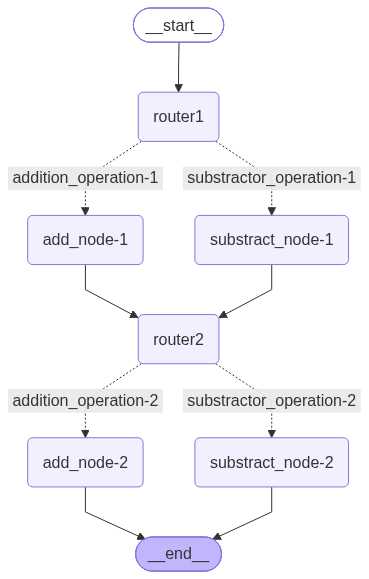

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
initial_state = AgentState(number1 = 10, operator1="-", number2 = 5, number3 = 7, number4=2, operator2="+", finalNumber= 0, finalNumber2 = 0)

In [19]:
print(app.invoke(initial_state))

{'number1': 10, 'number2': 5, 'number3': 7, 'number4': 2, 'operator1': '-', 'operator2': '+', 'result1': 5, 'result2': 9}
